# Why the stratosphere cools: a spectral tour

This notebook dissects the longwave radiation field of a standard Earth atmosphere
**band by band**, using climt's CORK (`CorkLongwaveRadiation`) component in
correlated-k mode with the shipped `earth_low_res_lw` 14-band table.

Key questions answered:

1. Which spectral bands are optically thick (opaque) and which are transparent?
2. How does per-band transmittance vary with pressure?
3. Where does each band cool (or warm) the atmosphere?
4. What happens to **optical depth**, **heating rate**, and **OLR** when CO₂ doubles?

All per-band diagnostics are read directly from the component — nothing is
re-computed by hand.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sympl
import xarray as xr
import pathlib, os

from climt import get_default_state, get_grid
from climt._components.cork import CorkLongwaveRadiation

sympl.set_backend(sympl.DataArrayBackend())
print('climt CORK notebook ready')

climt CORK notebook ready


## 1. Load a standard Earth atmosphere

We use `get_default_state` to build a 30-level column with climt's built-in
standard-atmosphere profiles, then add a realistic specific humidity profile
and set pre-industrial CO₂ (280 ppm).

The component is instantiated with `optics='correlated_k'` and the
`earth_low_res_lw` table (14 bands, 8 g-points per band).  In Parmentier mode
(`optics='parmentier'`, the default) all opacity is folded into two analytical
bands — suitable for exoplanet exploration but unable to resolve the CO₂
forcing experiment below.

In [2]:
# --- instantiate CORK in correlated-k mode with the Earth LW table -----------
lw = CorkLongwaveRadiation(optics='correlated_k', table='earth_low_res_lw')

print(f'Number of LW bands : {lw.num_longwave_bands}')
print(f'Has CO2 axis       : {lw._has_co2_axis}')

# --- read band edges from the shipped k-table --------------------------------
_repo = pathlib.Path(os.path.abspath('')).parent   # climt/ repo root (examples/../)
_nc   = _repo / 'climt' / '_data' / 'cork' / 'correlated_k' / 'earth_low_res_lw.nc'
ds_table = xr.open_dataset(str(_nc))
band_edges = ds_table['band_wavenumber_limits'].values   # (14, 2) in cm⁻¹
ds_table.close()

band_labels = [
    f'{int(lo)}–{int(hi)} cm⁻¹'
    for lo, hi in band_edges
]
print('\nBand edges (cm⁻¹):')
for i, lbl in enumerate(band_labels):
    print(f'  Band {i:2d}: {lbl}')

Number of LW bands : 14
Has CO2 axis       : True

Band edges (cm⁻¹):
  Band  0: 10–250 cm⁻¹
  Band  1: 250–350 cm⁻¹
  Band  2: 350–500 cm⁻¹
  Band  3: 500–630 cm⁻¹
  Band  4: 630–700 cm⁻¹
  Band  5: 700–800 cm⁻¹
  Band  6: 800–980 cm⁻¹
  Band  7: 980–1080 cm⁻¹
  Band  8: 1080–1180 cm⁻¹
  Band  9: 1180–1250 cm⁻¹
  Band 10: 1250–1400 cm⁻¹
  Band 11: 1400–1600 cm⁻¹
  Band 12: 1600–1800 cm⁻¹
  Band 13: 1800–3250 cm⁻¹


In [3]:
# --- build the input state ---------------------------------------------------
NZ = 30
grid = get_grid(nx=1, ny=1, nz=NZ)
state = get_default_state([lw], grid_state=grid)

# Pressure levels (Pa) — used as the vertical coordinate throughout
p_mid = state['air_pressure'].values[:, 0, 0]       # (NZ,) in Pa
p_hPa = p_mid / 100.0                               # convert to hPa

# Realistic humidity: ~10 g/kg near surface, falling off with altitude
q_profile = 1e-2 * np.exp(-p_hPa / 800.0)
state['specific_humidity'].values[:, 0, 0] = q_profile

# Pre-industrial CO₂: 280 ppm
CO2_PREINDUSTRIAL = 280e-6   # mole/mole
state['mole_fraction_of_carbon_dioxide_in_air'].values[:] = CO2_PREINDUSTRIAL

print('State summary:')
print(f'  Levels        : {NZ}')
print(f'  p range       : {p_hPa.min():.1f} – {p_hPa.max():.1f} hPa')
print(f'  T range       : {state["air_temperature"].values.min():.1f} – '
      f'{state["air_temperature"].values.max():.1f} K')
print(f'  q range       : {state["specific_humidity"].values.min():.2e} – '
      f'{state["specific_humidity"].values.max():.2e} kg/kg')
print(f'  CO₂           : {CO2_PREINDUSTRIAL*1e6:.0f} ppm')

State summary:
  Levels        : 30
  p range       : 2.4 – 1010.6 hPa
  T range       : 290.0 – 290.0 K
  q range       : 2.83e-03 – 9.97e-03 kg/kg
  CO₂           : 280 ppm


In [4]:
# --- run the CORK LW component -----------------------------------------------
tendencies, diagnostics = lw(state)

# Extract per-band diagnostics: shape (NZ, 1, 1, Nbands) for mid-level fields
tau_band   = diagnostics['longwave_optical_depth_per_band'].values[:, 0, 0, :]   # (NZ, Nbands)
trans_band = diagnostics['longwave_transmittance_per_band'].values[:, 0, 0, :]   # (NZ, Nbands)
hr_band    = diagnostics['air_temperature_tendency_from_longwave_per_band'].values[:, 0, 0, :]  # (NZ, Nbands)

# Per-band flux: shape (NZ+1, 1, 1, Nbands) on interface levels
up_band   = diagnostics['upwelling_longwave_flux_in_air_per_band'].values[:, 0, 0, :]    # (NZ+1, Nbands)
down_band = diagnostics['downwelling_longwave_flux_in_air_per_band'].values[:, 0, 0, :]  # (NZ+1, Nbands)

# Band-integrated (broadband)
up_broad   = diagnostics['upwelling_longwave_flux_in_air'].values[:, 0, 0]    # (NZ+1,)
down_broad = diagnostics['downwelling_longwave_flux_in_air'].values[:, 0, 0]  # (NZ+1,)
hr_broad   = diagnostics['air_temperature_tendency_from_longwave'].values[:, 0, 0]  # (NZ,)

# Verify per-band sums match broadband
np.testing.assert_allclose(up_band.sum(axis=-1), up_broad, rtol=1e-8,
                           err_msg='Per-band upwelling flux does not sum to broadband')
np.testing.assert_allclose(hr_band.sum(axis=-1), hr_broad, rtol=1e-8,
                           err_msg='Per-band heating rates do not sum to broadband')

# OLR = upwelling flux at TOA (top interface level)
OLR_baseline = float(up_broad[-1])

NBANDS = tau_band.shape[1]
print(f'Bands returned: {NBANDS}')
print(f'OLR (280 ppm CO₂): {OLR_baseline:.2f} W m⁻²')
print(f'Peak broadband heating rate: {hr_broad.min():.2f} K/day (at p={p_hPa[np.argmin(hr_broad)]:.1f} hPa)')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Bands returned: 14
OLR (280 ppm CO₂): 413.65 W m⁻²
Peak broadband heating rate: -79.03 K/day (at p=2.4 hPa)


## 2. Per-band optical depth τ(p)

The optical depth of each layer tells us how opaque it is in that band.
Large τ means the layer absorbs (and re-emits) radiation locally;
small τ means photons escape to space — this is the **window region**.

The 15 μm CO₂ band (630–700 cm⁻¹, Band 4) dominates in the upper troposphere
and stratosphere; the atmospheric window (800–980 cm⁻¹, Band 6) stays
transparent throughout.

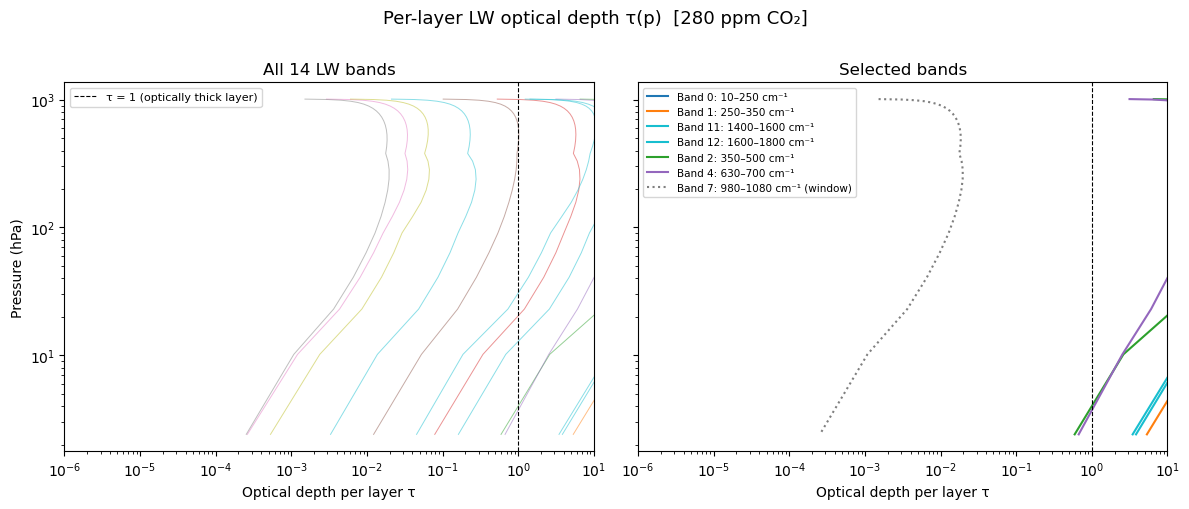

Most opaque band   : Band 0 — 10–250 cm⁻¹
Most transparent   : Band 7 — 980–1080 cm⁻¹


In [5]:
# --- Figure 1: per-band optical depth τ(p) -----------------------------------
# Identify the 6 most interesting bands by total column optical depth
col_tau = tau_band.sum(axis=0)    # (Nbands,) — column-integrated τ
top6    = np.argsort(col_tau)[::-1][:6]   # indices of 6 most optically thick bands

cmap = plt.cm.tab10
colors = [cmap(i) for i in range(NBANDS)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left panel: all 14 bands (thin lines)
ax = axes[0]
for b in range(NBANDS):
    ax.semilogy(tau_band[:, b], p_hPa, lw=0.7, alpha=0.5, color=colors[b])
ax.invert_yaxis()
ax.set_xlabel('Optical depth per layer τ')
ax.set_ylabel('Pressure (hPa)')
ax.set_title('All 14 LW bands')
ax.set_xscale('log')
ax.set_xlim(1e-6, 10)
ax.axvline(1.0, color='k', lw=0.8, ls='--', label='τ = 1 (optically thick layer)')
ax.legend(fontsize=8)

# Right panel: top 6 bands with labels
ax = axes[1]
for b in top6:
    ax.semilogy(tau_band[:, b], p_hPa, lw=1.5, color=colors[b],
                label=f'Band {b}: {band_labels[b]}')
# Also plot the most transparent band
least_opaque = int(np.argmin(col_tau))
if least_opaque not in top6:
    ax.semilogy(tau_band[:, least_opaque], p_hPa, lw=1.5, ls=':', color=colors[least_opaque],
                label=f'Band {least_opaque}: {band_labels[least_opaque]} (window)')
ax.axvline(1.0, color='k', lw=0.8, ls='--')
ax.invert_yaxis()
ax.set_xlabel('Optical depth per layer τ')
ax.set_title('Selected bands')
ax.set_xscale('log')
ax.set_xlim(1e-6, 10)
ax.legend(fontsize=7.5)

fig.suptitle('Per-layer LW optical depth τ(p)  [280 ppm CO₂]', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Most opaque band   : Band {top6[0]} — {band_labels[top6[0]]}')
print(f'Most transparent   : Band {least_opaque} — {band_labels[least_opaque]}')

## 3. Per-band layer transmittance

The transmittance $T_{\rm layer} = e^{-D\,\tau}$ (where the diffusivity
factor $D = 1.66$ accounts for off-axis photon paths) is directly returned by
the component.  A transmittance near 1 means the layer is essentially
transparent; near 0 it is opaque.

The atmospheric window bands (low τ) stay near transmittance = 1 throughout
the column — radiation escapes to space with little impediment, making these
bands responsible for most of the **cooling to space** in clear sky.

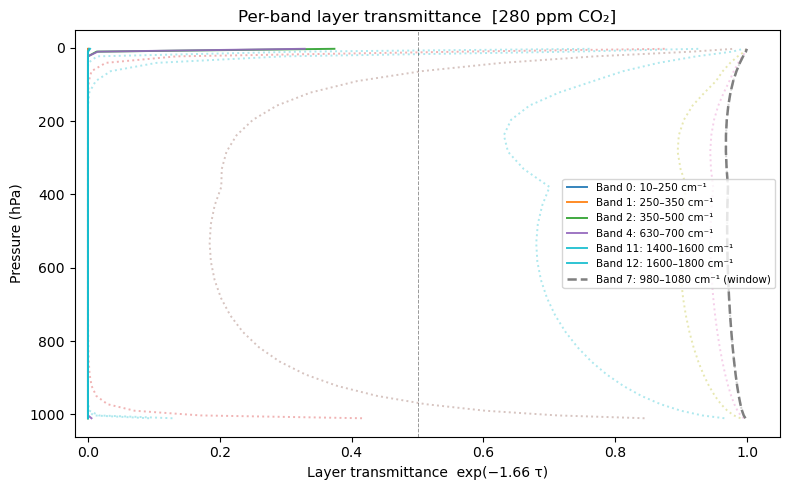

In [6]:
# --- Figure 2: per-band layer transmittance ----------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

for b in range(NBANDS):
    lw_style = '-' if b in top6 else ':'
    alpha    = 0.9 if b in top6 else 0.35
    label    = f'Band {b}: {band_labels[b]}' if b in top6 else None
    ax.plot(trans_band[:, b], p_hPa, lw=1.4, ls=lw_style, alpha=alpha,
            color=colors[b], label=label)

# Add the window band separately if not in top6
if least_opaque not in top6:
    ax.plot(trans_band[:, least_opaque], p_hPa, lw=1.8, ls='--',
            color=colors[least_opaque],
            label=f'Band {least_opaque}: {band_labels[least_opaque]} (window)')

ax.invert_yaxis()
ax.set_xlabel('Layer transmittance  exp(−1.66 τ)')
ax.set_ylabel('Pressure (hPa)')
ax.set_title('Per-band layer transmittance  [280 ppm CO₂]')
ax.legend(fontsize=7.5, loc='center right')
ax.set_xlim(-0.02, 1.05)
ax.axvline(0.5, color='k', lw=0.7, ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 4. Per-band net longwave flux profiles

Net flux = upwelling − downwelling.  A large positive net flux means
radiation is escaping efficiently upward with little downward return — typical
of the window band.  In the strong absorption bands the atmosphere is
nearly in local thermal equilibrium and the net flux is small.

Note that the broadband net flux (dashed black) is the sum of all per-band
contributions.

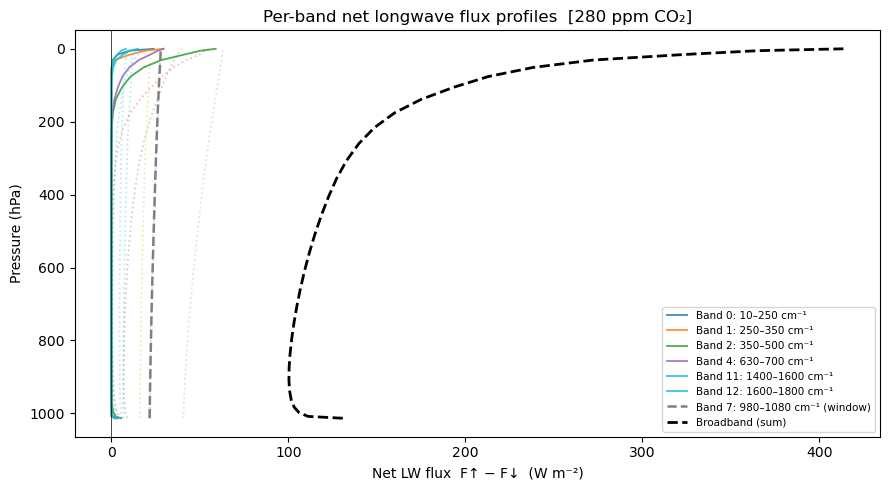

Broadband OLR (top interface): 413.65 W m⁻²
Per-band OLR contributions at TOA:
  Band  0 (       10–250 cm⁻¹):  +23.98 W m⁻²
  Band  1 (      250–350 cm⁻¹):  +29.32 W m⁻²
  Band  2 (      350–500 cm⁻¹):  +58.95 W m⁻²
  Band  3 (      500–630 cm⁻¹):  +56.31 W m⁻²
  Band  4 (      630–700 cm⁻¹):  +29.49 W m⁻²
  Band  5 (      700–800 cm⁻¹):  +39.62 W m⁻²
  Band  6 (      800–980 cm⁻¹):  +62.78 W m⁻²
  Band  7 (     980–1080 cm⁻¹):  +27.83 W m⁻²
  Band  8 (    1080–1180 cm⁻¹):  +22.32 W m⁻²
  Band  9 (    1180–1250 cm⁻¹):  +12.30 W m⁻²
  Band 10 (    1250–1400 cm⁻¹):  +18.39 W m⁻²
  Band 11 (    1400–1600 cm⁻¹):  +15.00 W m⁻²
  Band 12 (    1600–1800 cm⁻¹):   +8.11 W m⁻²
  Band 13 (    1800–3250 cm⁻¹):   +9.26 W m⁻²


In [7]:
# --- Figure 3: per-band net flux profiles ------------------------------------
# Flux arrays are on interface levels (NZ+1 points); use mid-point for plotting
p_int = state['air_pressure_on_interface_levels'].values[:, 0, 0]   # (NZ+1,)
p_int_hPa = p_int / 100.0

net_band  = up_band - down_band    # (NZ+1, Nbands)
net_broad = up_broad - down_broad  # (NZ+1,)

fig, ax = plt.subplots(figsize=(9, 5))

for b in range(NBANDS):
    lw_style = '-' if b in top6 else ':'
    alpha    = 0.85 if b in top6 else 0.3
    label    = f'Band {b}: {band_labels[b]}' if b in top6 else None
    ax.plot(net_band[:, b], p_int_hPa, lw=1.3, ls=lw_style, alpha=alpha,
            color=colors[b], label=label)

if least_opaque not in top6:
    ax.plot(net_band[:, least_opaque], p_int_hPa, lw=1.8, ls='--',
            color=colors[least_opaque],
            label=f'Band {least_opaque}: {band_labels[least_opaque]} (window)')

ax.plot(net_broad, p_int_hPa, 'k--', lw=2.0, label='Broadband (sum)')

ax.invert_yaxis()
ax.set_xlabel('Net LW flux  F↑ − F↓  (W m⁻²)')
ax.set_ylabel('Pressure (hPa)')
ax.set_title('Per-band net longwave flux profiles  [280 ppm CO₂]')
ax.legend(fontsize=7.5)
ax.axvline(0, color='k', lw=0.5)
plt.tight_layout()
plt.show()

print(f'Broadband OLR (top interface): {net_broad[-1]:.2f} W m⁻²')
print(f'Per-band OLR contributions at TOA:')
for b in range(NBANDS):
    print(f'  Band {b:2d} ({band_labels[b]:>18s}): {net_band[-1, b]:+7.2f} W m⁻²')

## 5. Per-band heating-rate contributions

The radiative heating rate (K day⁻¹) is the divergence of the net flux.
Negative heating rates mean **cooling** — the layer loses energy to space
faster than it receives it from below.

The per-band heating rates sum exactly to the broadband rate.  This lets us
decompose the stratospheric cooling signal into spectral contributions:
which bands are responsible for the −2 K/day cooling at 30 hPa?

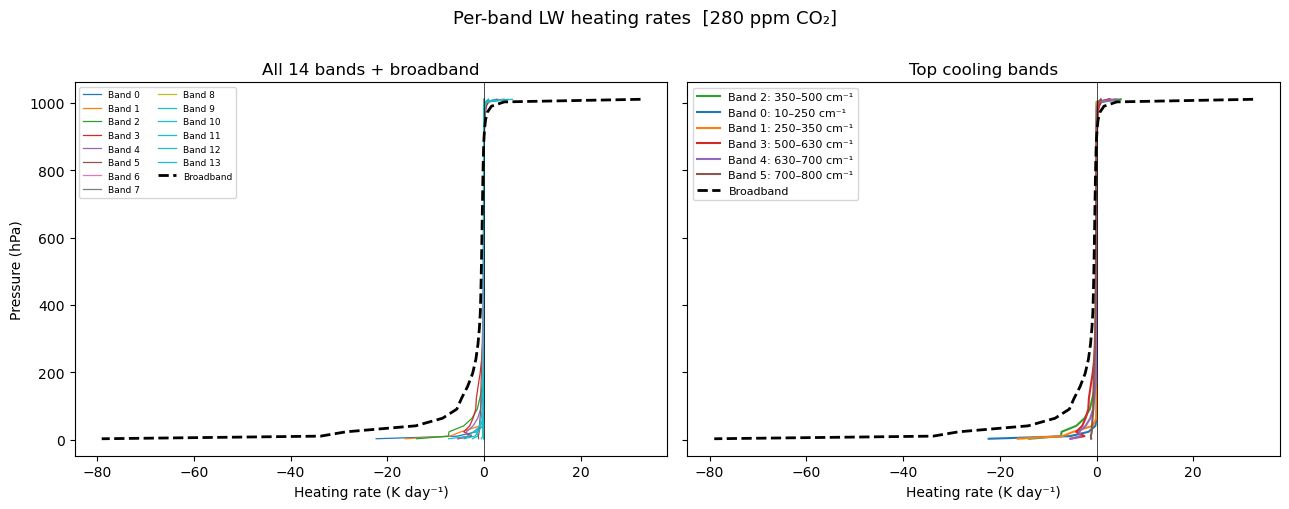

Broadband peak cooling: -79.03 K/day at 2.4 hPa
Top 3 cooling bands (column-mean K/day):
  Band  2 (      350–500 cm⁻¹): -1.052 K/day
  Band  0 (       10–250 cm⁻¹): -0.896 K/day
  Band  1 (      250–350 cm⁻¹): -0.839 K/day


In [8]:
# --- Figure 4: per-band heating-rate contributions ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Left: all bands stacked
ax = axes[0]
hr_sum = np.zeros(NZ)
for b in range(NBANDS):
    ax.plot(hr_band[:, b], p_hPa, lw=0.9, color=colors[b],
            label=f'Band {b}')
ax.plot(hr_broad, p_hPa, 'k--', lw=2.0, label='Broadband')
ax.axvline(0, color='k', lw=0.5)
ax.invert_yaxis()
ax.set_xlabel('Heating rate (K day⁻¹)')
ax.set_ylabel('Pressure (hPa)')
ax.set_title('All 14 bands + broadband')
ax.legend(fontsize=6.5, ncol=2)

# Right: selected bands only — the dominant cooling contributors
ax = axes[1]

# Find the bands with strongest (most negative) column-mean heating rates
mean_hr = hr_band.mean(axis=0)   # (Nbands,)
top_cooling = np.argsort(mean_hr)[:6]   # most negative = most cooling

for b in top_cooling:
    ax.plot(hr_band[:, b], p_hPa, lw=1.5, color=colors[b],
            label=f'Band {b}: {band_labels[b]}')
ax.plot(hr_broad, p_hPa, 'k--', lw=2.0, label='Broadband')
ax.axvline(0, color='k', lw=0.5)
ax.invert_yaxis()
ax.set_xlabel('Heating rate (K day⁻¹)')
ax.set_title('Top cooling bands')
ax.legend(fontsize=8)

fig.suptitle('Per-band LW heating rates  [280 ppm CO₂]', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Broadband peak cooling: {hr_broad.min():.2f} K/day at '
      f'{p_hPa[np.argmin(hr_broad)]:.1f} hPa')
print('Top 3 cooling bands (column-mean K/day):')
for b in top_cooling[:3]:
    print(f'  Band {b:2d} ({band_labels[b]:>18s}): {mean_hr[b]:+.3f} K/day')

## 6. CO₂-doubling experiment

We run the component a second time with CO₂ doubled (560 ppm, 2× pre-industrial)
and compare:

- **Δτ per band** — which bands gain the most optical depth?
- **Δheating rate per band** — which bands change their cooling profile?
- **ΔOLR** — the instantaneous radiative forcing before temperature adjustment.

The `earth_low_res_lw` table has a CO₂ VMR axis, so the component reads
`mole_fraction_of_carbon_dioxide_in_air` from the state and interpolates in
the k-table — no code changes needed.

In [9]:
# --- Build a doubled-CO₂ state and run CORK ----------------------------------
import copy

CO2_DOUBLED = CO2_PREINDUSTRIAL * 2.0   # 560 ppm

state2 = get_default_state([lw], grid_state=grid)
# Copy the same humidity and temperature profile
state2['specific_humidity'].values[:, 0, 0] = q_profile
state2['mole_fraction_of_carbon_dioxide_in_air'].values[:] = CO2_DOUBLED

tendencies2, diagnostics2 = lw(state2)

# Extract doubled-CO₂ diagnostics
tau_band2 = diagnostics2['longwave_optical_depth_per_band'].values[:, 0, 0, :]
hr_band2  = diagnostics2['air_temperature_tendency_from_longwave_per_band'].values[:, 0, 0, :]
up_broad2 = diagnostics2['upwelling_longwave_flux_in_air'].values[:, 0, 0]

OLR_doubled = float(up_broad2[-1])
delta_OLR   = OLR_doubled - OLR_baseline

print(f'OLR (280 ppm): {OLR_baseline:.3f} W m⁻²')
print(f'OLR (560 ppm): {OLR_doubled:.3f} W m⁻²')
print(f'ΔOLR (CO₂ doubling): {delta_OLR:+.3f} W m⁻²')
print(f'(Negative ΔOLR = reduced emission to space = CO₂ forcing)')

OLR (280 ppm): 413.650 W m⁻²
OLR (560 ppm): 413.324 W m⁻²
ΔOLR (CO₂ doubling): -0.325 W m⁻²
(Negative ΔOLR = reduced emission to space = CO₂ forcing)


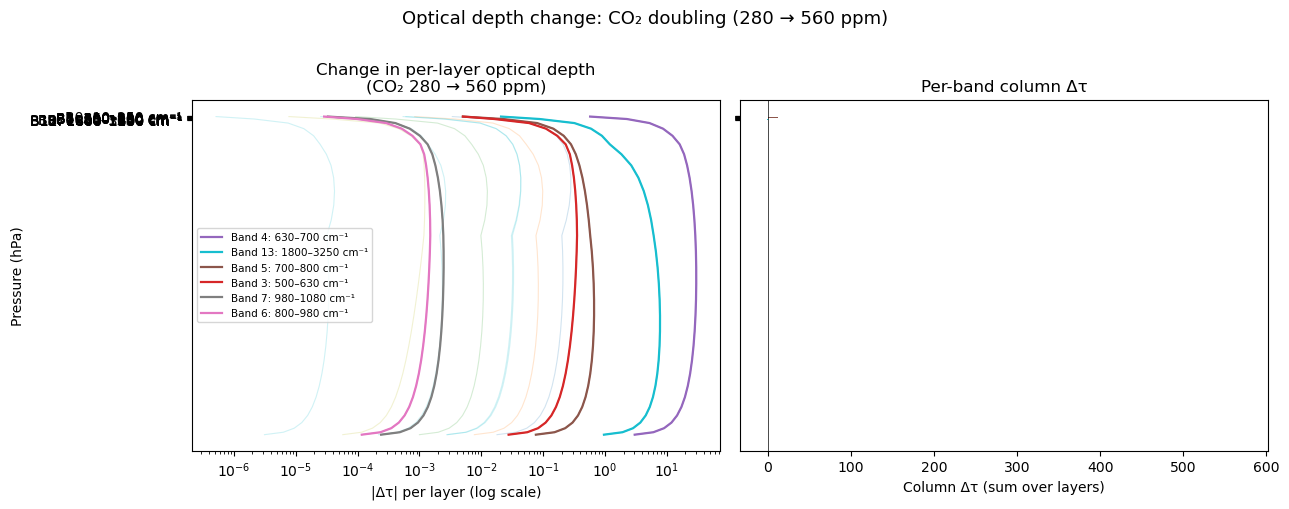

Top 5 bands by column Δτ (CO₂ doubling):
  Band  4 (      630–700 cm⁻¹): Δτ_col = +573.4176
  Band 13 (    1800–3250 cm⁻¹): Δτ_col = +130.2006
  Band  5 (      700–800 cm⁻¹): Δτ_col = +12.3269
  Band  3 (      500–630 cm⁻¹): Δτ_col = +6.5097
  Band  7 (     980–1080 cm⁻¹): Δτ_col = +0.0471


In [10]:
# --- Figure 5: Δτ per band ---------------------------------------------------
delta_tau = tau_band2 - tau_band    # (NZ, Nbands)

# Find bands with largest increase in column optical depth
col_delta_tau = delta_tau.sum(axis=0)   # (Nbands,)
top_delta     = np.argsort(col_delta_tau)[::-1][:6]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

ax = axes[0]
for b in range(NBANDS):
    alpha = 0.9 if b in top_delta else 0.2
    ax.semilogx(np.abs(delta_tau[:, b]) + 1e-10, p_hPa, lw=0.8,
                alpha=alpha, color=colors[b])
for b in top_delta:
    ax.semilogx(np.abs(delta_tau[:, b]) + 1e-10, p_hPa, lw=1.6,
                color=colors[b], label=f'Band {b}: {band_labels[b]}')
ax.invert_yaxis()
ax.set_xlabel('|Δτ| per layer (log scale)')
ax.set_ylabel('Pressure (hPa)')
ax.set_title('Change in per-layer optical depth\n(CO₂ 280 → 560 ppm)')
ax.legend(fontsize=7.5)

# Bar chart of column-integrated Δτ
ax = axes[1]
bar_colors = [colors[b] for b in range(NBANDS)]
bars = ax.barh(range(NBANDS), col_delta_tau, color=bar_colors)
ax.set_yticks(range(NBANDS))
ax.set_yticklabels([f'B{b}: {band_labels[b]}' for b in range(NBANDS)], fontsize=7)
ax.set_xlabel('Column Δτ (sum over layers)')
ax.set_title('Per-band column Δτ')
ax.axvline(0, color='k', lw=0.5)

fig.suptitle('Optical depth change: CO₂ doubling (280 → 560 ppm)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Top 5 bands by column Δτ (CO₂ doubling):')
for b in top_delta[:5]:
    print(f'  Band {b:2d} ({band_labels[b]:>18s}): Δτ_col = {col_delta_tau[b]:+.4f}')

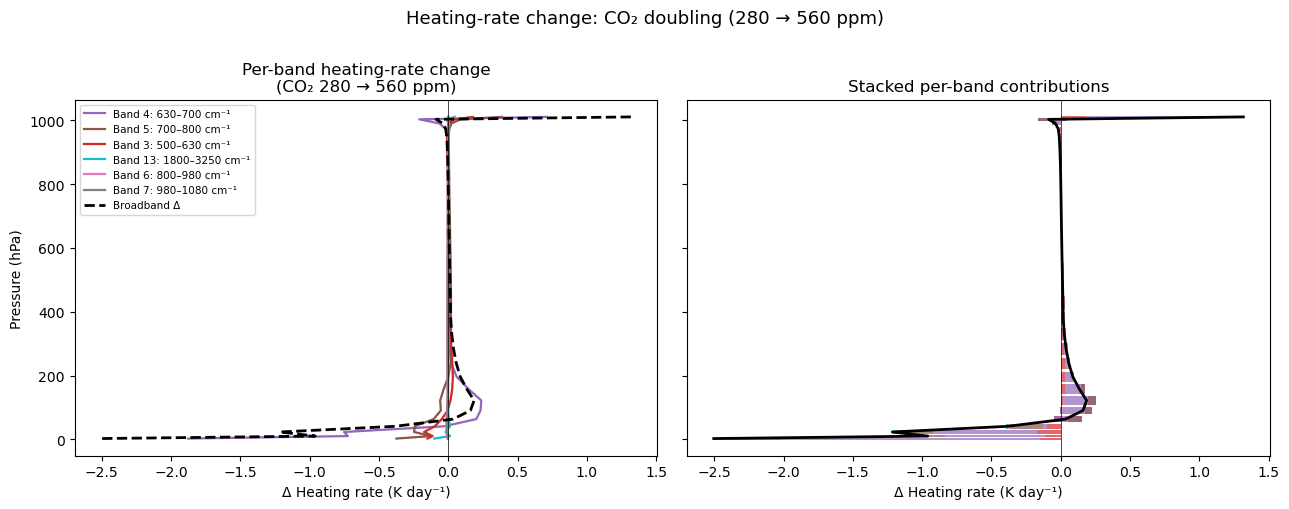

Broadband peak Δ heating rate: -2.503 K/day at 2.4 hPa
Top contributing bands to the Δ heating rate change:
  Band  4 (      630–700 cm⁻¹): column-mean Δ = -0.0685 K/day
  Band  5 (      700–800 cm⁻¹): column-mean Δ = -0.0169 K/day
  Band  3 (      500–630 cm⁻¹): column-mean Δ = -0.0075 K/day
  Band 13 (    1800–3250 cm⁻¹): column-mean Δ = -0.0017 K/day


In [11]:
# --- Figure 6: Δheating rate per band ----------------------------------------
delta_hr      = hr_band2 - hr_band      # (NZ, Nbands)
delta_hr_broad = diagnostics2['air_temperature_tendency_from_longwave'].values[:, 0, 0] - hr_broad

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Left: per-band Δheating rates
ax = axes[0]
top_delta_hr = np.argsort(np.abs(delta_hr).mean(axis=0))[::-1][:6]
for b in range(NBANDS):
    alpha = 0.85 if b in top_delta_hr else 0.2
    ax.plot(delta_hr[:, b], p_hPa, lw=0.8, alpha=alpha, color=colors[b])
for b in top_delta_hr:
    ax.plot(delta_hr[:, b], p_hPa, lw=1.6, color=colors[b],
            label=f'Band {b}: {band_labels[b]}')
ax.plot(delta_hr_broad, p_hPa, 'k--', lw=2.0, label='Broadband Δ')
ax.axvline(0, color='k', lw=0.5)
ax.invert_yaxis()
ax.set_xlabel('Δ Heating rate (K day⁻¹)')
ax.set_ylabel('Pressure (hPa)')
ax.set_title('Per-band heating-rate change\n(CO₂ 280 → 560 ppm)')
ax.legend(fontsize=7.5)

# Right: broadband Δ heating rate with per-band decomposition
ax = axes[1]
x = np.zeros(NZ)
for b in range(NBANDS):
    ax.barh(p_hPa, delta_hr[:, b], left=x, height=np.gradient(p_hPa)*0.8,
            color=colors[b], alpha=0.7, label=f'B{b}')
    x = x + delta_hr[:, b]
ax.plot(delta_hr_broad, p_hPa, 'k-', lw=2.0, label='Broadband Δ')
ax.axvline(0, color='k', lw=0.5)
ax.invert_yaxis()
ax.set_xlabel('Δ Heating rate (K day⁻¹)')
ax.set_title('Stacked per-band contributions')

fig.suptitle('Heating-rate change: CO₂ doubling (280 → 560 ppm)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Broadband peak Δ heating rate: {delta_hr_broad.min():.3f} K/day at '
      f'{p_hPa[np.argmin(delta_hr_broad)]:.1f} hPa')
print('Top contributing bands to the Δ heating rate change:')
for b in top_delta_hr[:4]:
    mean_Δhr = delta_hr[:, b].mean()
    print(f'  Band {b:2d} ({band_labels[b]:>18s}): column-mean Δ = {mean_Δhr:+.4f} K/day')

## 7. Summary: the CO₂ forcing decomposed

The instantaneous (fixed-atmosphere) forcing from CO₂ doubling is the ΔOLR
computed above — the reduction in outgoing longwave radiation before any
temperature response.  A more negative ΔOLR means stronger radiative forcing.

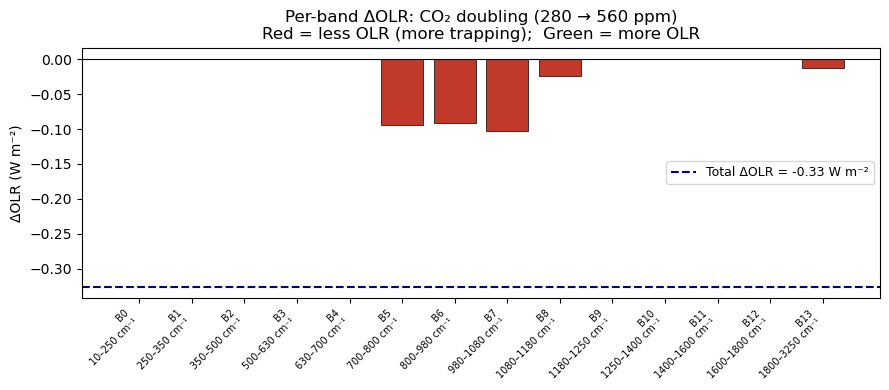

CO₂-doubling summary:
  OLR (280 ppm) :  413.650 W m⁻²
  OLR (560 ppm) :  413.324 W m⁻²
  ΔOLR          :   -0.325 W m⁻²

Per-band ΔOLR breakdown:
  Band  0 (       10–250 cm⁻¹): +0.000 W m⁻²
  Band  1 (      250–350 cm⁻¹): +0.000 W m⁻²
  Band  2 (      350–500 cm⁻¹): +0.000 W m⁻²
  Band  3 (      500–630 cm⁻¹): -0.000 W m⁻²
  Band  4 (      630–700 cm⁻¹): +0.000 W m⁻²
  Band  5 (      700–800 cm⁻¹): -0.094 W m⁻²
  Band  6 (      800–980 cm⁻¹): -0.091 W m⁻²
  Band  7 (     980–1080 cm⁻¹): -0.102 W m⁻²  <-- CO₂ bands
  Band  8 (    1080–1180 cm⁻¹): -0.025 W m⁻²
  Band  9 (    1180–1250 cm⁻¹): +0.000 W m⁻²
  Band 10 (    1250–1400 cm⁻¹): +0.000 W m⁻²
  Band 11 (    1400–1600 cm⁻¹): +0.000 W m⁻²
  Band 12 (    1600–1800 cm⁻¹): +0.000 W m⁻²
  Band 13 (    1800–3250 cm⁻¹): -0.013 W m⁻²


In [12]:
# --- Figure 7: ΔOLR per band -------------------------------------------------
net_band2 = (diagnostics2['upwelling_longwave_flux_in_air_per_band'].values[:, 0, 0, :]
             - diagnostics2['downwelling_longwave_flux_in_air_per_band'].values[:, 0, 0, :])

delta_OLR_band = net_band2[-1, :] - net_band[-1, :]   # change in TOA net flux per band

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors_signed = ['#c0392b' if d < 0 else '#27ae60' for d in delta_OLR_band]
ax.bar(range(NBANDS), delta_OLR_band, color=bar_colors_signed, edgecolor='k', lw=0.5)
ax.axhline(0, color='k', lw=0.8)
ax.axhline(delta_OLR, color='navy', lw=1.5, ls='--',
           label=f'Total ΔOLR = {delta_OLR:+.2f} W m⁻²')
ax.set_xticks(range(NBANDS))
ax.set_xticklabels([f'B{b}\n{band_labels[b]}' for b in range(NBANDS)],
                   rotation=45, ha='right', fontsize=7)
ax.set_ylabel('ΔOLR (W m⁻²)')
ax.set_title('Per-band ΔOLR: CO₂ doubling (280 → 560 ppm)\n'
             'Red = less OLR (more trapping);  Green = more OLR')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('CO₂-doubling summary:')
print(f'  OLR (280 ppm) : {OLR_baseline:8.3f} W m⁻²')
print(f'  OLR (560 ppm) : {OLR_doubled:8.3f} W m⁻²')
print(f'  ΔOLR          : {delta_OLR:+8.3f} W m⁻²')
print()
print('Per-band ΔOLR breakdown:')
for b in range(NBANDS):
    flag = '  <-- CO₂ bands' if abs(delta_OLR_band[b]) > 0.1 else ''
    print(f'  Band {b:2d} ({band_labels[b]:>18s}): {delta_OLR_band[b]:+.3f} W m⁻²{flag}')

## 8. Takeaways

1. **Window bands are transparent** (low τ, transmittance ≈ 1) and contribute
   most of the OLR from lower-tropospheric levels.

2. **CO₂ and H₂O rotation bands are opaque** (high τ) and keep the troposphere
   in radiative-convective balance by absorbing upwelling radiation and
   re-emitting at the local temperature.

3. **Stratospheric cooling** is driven by the CO₂ 15 μm band: the stratosphere
   absorbs little from below but emits efficiently to space, producing the
   characteristic −2 K/day cooling above the tropopause.

4. **CO₂ doubling reduces OLR** by increasing the optical depth in the 15 μm
   band — the ΔOLR value computed above is the instantaneous radiative forcing
   before any temperature feedback.

5. The CORK component (correlated-k mode) resolves all of this with just 14
   bands × 8 g-points per band = **112 quadrature points**, compared to
   thousands of spectral lines in a line-by-line calculation.

---

**Next steps:**
- Chapter 7 of the climt docs walkthrough extends this analysis to the
  two-stream SW component (`CorkShortwaveRadiation`).
- `examples/k_distribution_demo.ipynb` shows how the k-distribution quadrature
  is derived from first principles.
- The CORK architecture is explained in Chapter 5 and the [CORK component manual](../component-manual/cork.qmd).